# Ideal Motion Model (1D Constant Acceleration)

In this notebook, we simulate the 1D motion of an object moving with **constant acceleration** ($a = 2 \text{ m/s}^2$) without any external forces like air drag.

### 1. Importing Libraries
- **`matplotlib.pyplot`**: Used for plotting and visualizing kinematic graphs.
- **`numpy`**: Used for numerical operations and array manipulation.

I added time as np.array to visualize the difference between ploting.

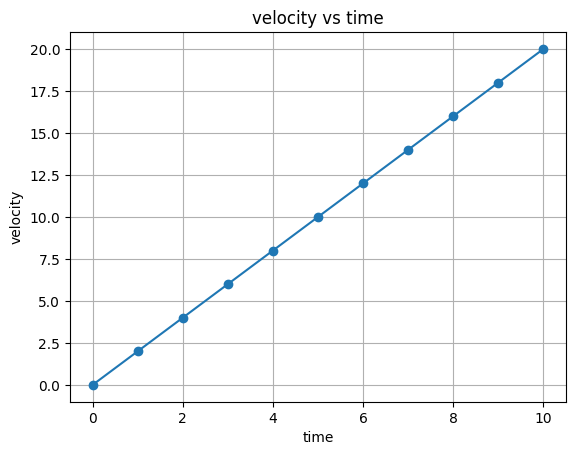

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

t=np.array([0,1,2,3,4,5,6,7,8,9,10])
a=2
v=a*t
plt.plot(t,v,marker='o')
plt.title("velocity vs time")
plt.xlabel("time")
plt.ylabel("velocity")
plt.grid(True)
plt.show()

### 2. Defining Time and Parameters
- **`np.linspace(0, 10, 100)`**: Generates 100 evenly spaced time points between $t = 0\text{s}$ and $t = 10\text{s}$. We use `linspace` instead of a small array to make curved plots smooth and continuous.
- **`a = 2`**: Sets a constant acceleration of $2 \text{ m/s}^2$.

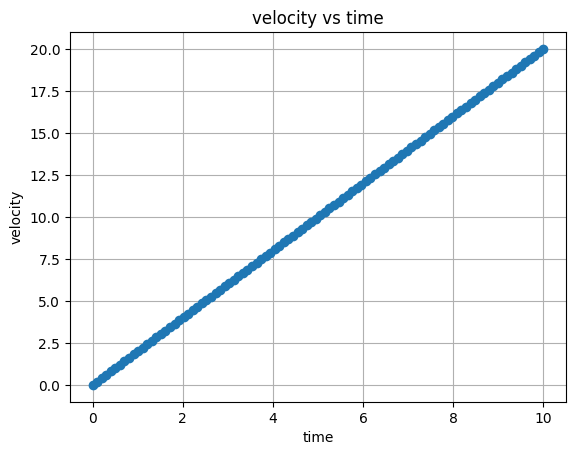

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

t=np.linspace(0,10,100)
a=2
v=a*t
plt.plot(t,v,marker='o')
plt.title("velocity vs time")
plt.xlabel("time")
plt.ylabel("velocity")
plt.grid(True)
plt.show()

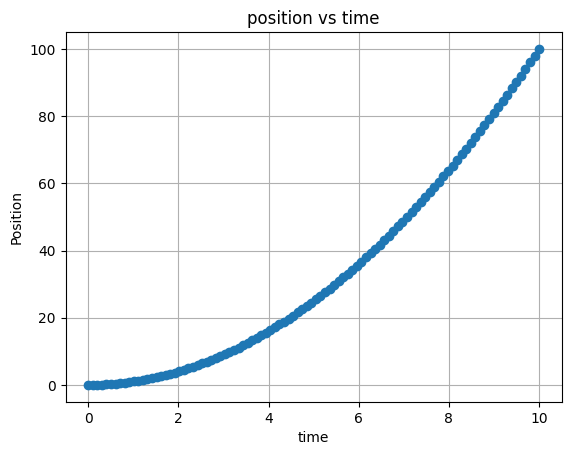

In [ ]:
t=np.linspace(0,10,100)
a=2
x=0.5*a*(t**2)
plt.plot(t,x,marker='o')
plt.title("position vs time")
plt.xlabel("time")
plt.ylabel("Position")
plt.grid(True)
plt.show()

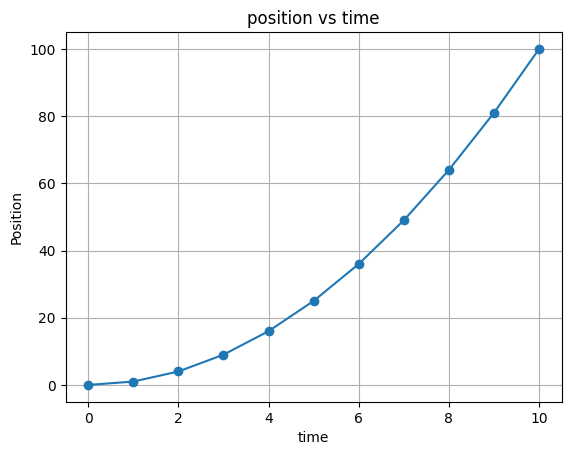

In [ ]:
t=np.array([0,1,2,3,4,5,6,7,8,9,10])
a=2
x=0.5*a*(t**2)
plt.plot(t,x,marker='o')
plt.title("position vs time")
plt.xlabel("time")
plt.ylabel("Position")
plt.grid(True)
plt.show()

The graph shows a sharp and straight lines in-between the points. Whereas, the linspace shows a smooth while highlighting each second journey.

### 3. Kinematic Calculations
- **Velocity ($v = a \cdot t$)**: Increases **linearly** because acceleration is constant (equal velocity increments in equal time intervals).
- **Position ($x = \frac{1}{2} a t^2$)**: Increases **quadratically** (curved) because as speed increases, the object covers greater distances in each subsequent second.

### 4. Data Visualization
We create side-by-side subplots (`1` row, `2` columns) to compare the behavior of Velocity vs. Position over time:
- **`plt.subplot(1, 2, 1)`**: Plotting Velocity vs. Time on the left.
- **`plt.subplot(1, 2, 2)`**: Plotting Position vs. Time on the right.

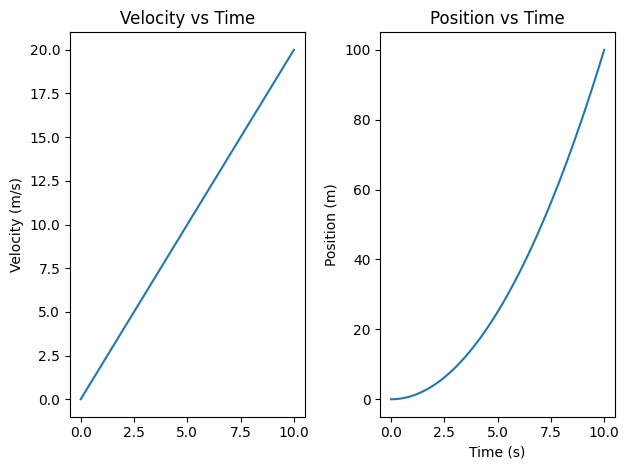

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

t = np.linspace(0, 10, 100)
a = 2

v = a * t
x = 0.5 * a * (t**2)

# 1st Graph: Velocity
plt.subplot(1, 2, 1)
plt.plot(t, v)
plt.title("Velocity vs Time")
plt.ylabel("Velocity (m/s)")

# 2nd Graph: Position
plt.subplot(1, 2, 2)
plt.plot(t, x)
plt.title("Position vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")

plt.tight_layout()
plt.show()

#**Real Motion Model**

In this part, I have included the factors affecting the motion such as drag force.

We'll add the values and libraries. Since, now I am measuring how acceleration and velocity are changing at a very small change of time, we'll add dt.





Now, we'll add the list to store our new values for speed, position, and time.

#Simulation Loop (Euler's Method)
We'll add loop, drag force formula, net_acceleration.

According to the net_acceleration and speed, we'll now calculate the speed,position,and time for next 0.01 sec.

To add the new values to the list.

#Plotting

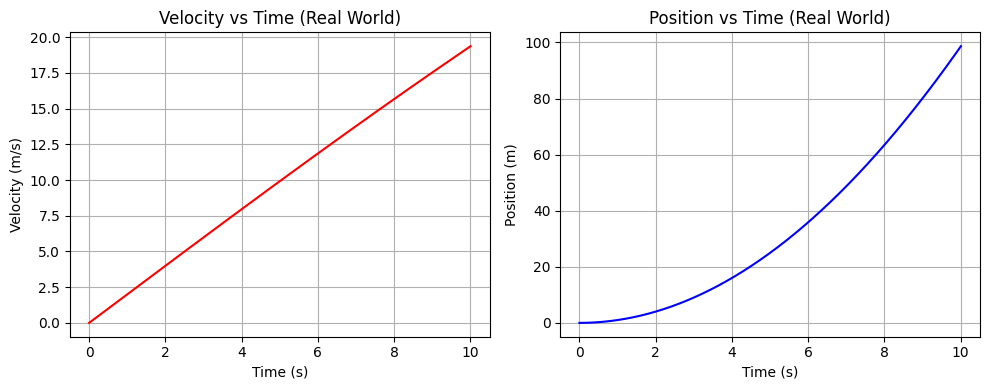

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Parameters & Initial Conditions
dt = 0.01  # Time step (s)
t_max = 10.0  # Total time (s)
m = 1000.0  # Car mass (kg)
F_engine = 2000.0  # Engine force (N)
c = 0.5  # Drag coefficient

t = 0.0
v = 0.0
x = 0.0

# Lists to store data for plotting
t_list = [t]
v_list = [v]
x_list = [x]

# 2. Simulation Loop (Euler's Method)
while t < t_max:
    F_drag = c * (v**2)  # Drag force
    a_net = (F_engine - F_drag) / m  # Acceleration

    v = v + a_net * dt  # Velocity update
    x = x + v * dt  # Position update
    t = t + dt  # Time update

    t_list.append(t)
    v_list.append(v)
    x_list.append(x)

# 3. Data Visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(t_list, v_list, 'r-')
plt.title('Velocity vs Time (Real World)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_list, x_list, 'b-')
plt.title('Position vs Time (Real World)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.grid(True)

plt.tight_layout()
plt.show()

#1D Rocket Launch

Provide the parameters

In [ ]:
g = 9.81
m_rocket = 500.0
m_fuel = 300.0
t_burn = 10.0
burn_rate = m_fuel / t_burn  # 30 kg/s
F_thrust = 15000.0
dt = 0.1

Lists for plotting

In [ ]:
t = [0.0]
y = [0.0]  # Height
v = [0.0]

#Euler's Simulation Loop

In [ ]:
while y[-1] >= 0:
    t_curr = t[-1]
# 1. Fuel & Mass check
    if t_curr <= t_burn:
        m_curr = (m_rocket + m_fuel) - (burn_rate * t_curr)
        F_curr = F_thrust
    else:
        m_curr = m_rocket
        F_curr = 0.0
    # 2. Acceleration calculation
    F_net = F_curr - (m_curr * g)
    a = F_net / m_curr

    # 3. Euler's method updates
    v_next = v[-1] + a * dt
    y_next = y[-1] + v[-1] * dt

    # Appending new values
    v.append(v_next)
    y.append(y_next)
    t.append(t_curr + dt)

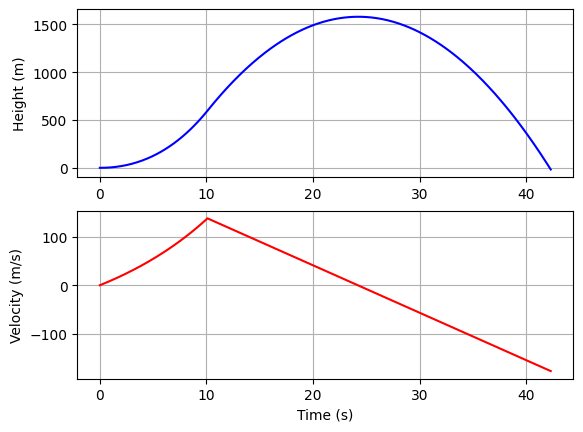

In [ ]:
import matplotlib.pyplot as plt

# 1. Height vs Time Graph
plt.subplot(2, 1, 1)
plt.plot(t, y, color="blue")
plt.ylabel("Height (m)")
plt.grid(True)

# 2. Velocity vs Time Graph
plt.subplot(2, 1, 2)
plt.plot(t, v, color="red")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)

plt.show()

#2D Satellite Orbital Setup

In [ ]:
G = 6.674e-11        # Gravitational constant
M = 5.972e24         # Earth mass (kg)
m = 1000.0           # Satellite mass (kg)
dt = 1.0

In [ ]:
x = [0.0]            # Starting at x = 0
y = [6771000.0]      # 400 km above Earth surface (meters)
vx = [7670.0]        # Orbital velocity (m/s)
vy = [0.0]

#Simulation Loop

In [ ]:
import numpy as np
for _ in range(5000):  # 5000 time steps
    rx = x[-1]
    ry = y[-1]
    r = np.sqrt(rx**2 + ry**2)
    # Force & Acceleration
    F = (G * M * m) / (r**2)
    Fx = -F * (rx / r)
    Fy = -F * (ry / r)

    ax = Fx / m
    ay = Fy / m

    # Euler Updates
    vx_next = vx[-1] + ax * dt
    vy_next = vy[-1] + ay * dt
    x_next = x[-1] + vx[-1] * dt
    y_next = y[-1] + vy[-1] * dt
    # Store
    vx.append(vx_next)
    vy.append(vy_next)
    x.append(x_next)
    y.append(y_next)

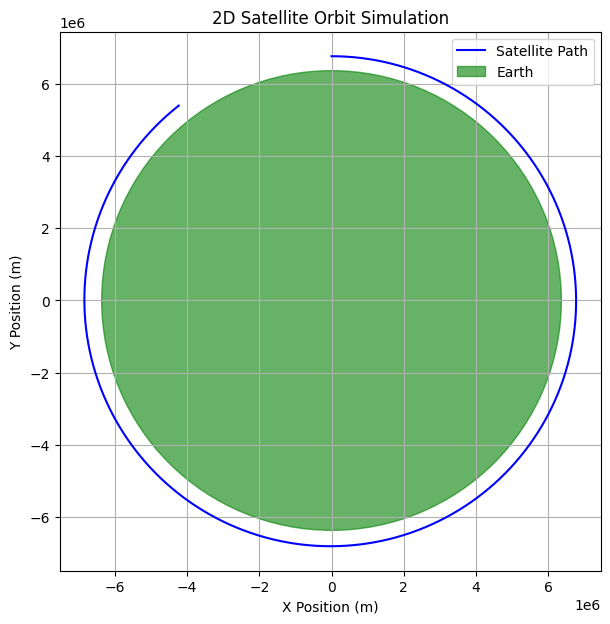

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.plot(x, y, color="blue", label="Satellite Path")

earth = plt.Circle((0, 0), 6371000, color="green", alpha=0.6, label="Earth")
plt.gca().add_patch(earth)

plt.gca().set_aspect("equal")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("2D Satellite Orbit Simulation")
plt.grid(True)
plt.legend()

plt.show()


#Atmospheric drag and orbital drag

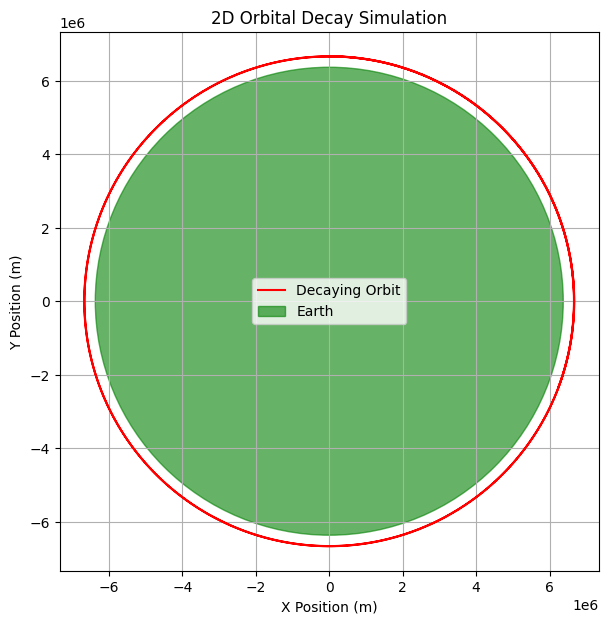

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Constants
G = 6.674e-11        # Gravitational constant
M = 5.972e24         # Earth mass (kg)
R_E = 6371000.0      # Earth radius (meters)

# 2. Satellite & Drag Parameters
m = 1000.0           # Satellite mass (kg)
A = 10.0             # Area (m^2)
Cd = 2.2             # Drag coefficient
rho = 5e-10          # Air density (exaggerated for fast visualization)

# 3. Initial Conditions (300 km height)
x = [0.0]
y = [R_E + 300000.0]
vx = [7730.0]        # Horizontal speed (m/s)
vy = [0.0]
dt = 0.5             # Time step (seconds)

# 4. Simulation Loop
for _ in range(25000):
    rx = x[-1]
    ry = y[-1]
    r = np.sqrt(rx**2 + ry**2)

    # Crash check
    if r <= R_E:
        print("Satellite crashed")
        break

    # Gravity
    F_grav = (G * M * m) / (r**2)
    Fx_grav = -F_grav * (rx / r)
    Fy_grav = -F_grav * (ry / r)

    # Drag
    v_mag = np.sqrt(vx[-1]**2 + vy[-1]**2)
    F_drag = 0.5 * rho * (v_mag**2) * Cd * A
    Fx_drag = -F_drag * (vx[-1] / v_mag)
    Fy_drag = -F_drag * (vy[-1] / v_mag)

    # Net Acceleration
    ax = (Fx_grav + Fx_drag) / m
    ay = (Fy_grav + Fy_drag) / m

    # Euler Updates
    vx.append(vx[-1] + ax * dt)
    vy.append(vy[-1] + ay * dt)
    x.append(x[-1] + vx[-1] * dt)
    y.append(y[-1] + vy[-1] * dt)

# 5. Plotting
plt.figure(figsize=(7, 7))
plt.plot(x, y, color="red", label="Decaying Orbit")

earth = plt.Circle((0, 0), R_E, color="green", alpha=0.6, label="Earth")
plt.gca().add_patch(earth)

plt.gca().set_aspect("equal")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("2D Orbital Decay Simulation")
plt.grid(True)
plt.legend()
plt.show()

## Transitioning from Euler's Method to RK45 (Runge-Kutta 4th/5th Order)

While **Euler's Method** provides a basic introduction to numerical integration, it is insufficient for accurate orbital mechanics simulations due to key limitations:

### 1. Accuracy & Curvature Handling
* **Euler's Method (1st Order):** Assumes a constant slope ($k_1$) over the entire time step ($dt$). In curved trajectories (like planetary orbits), this causes severe truncation error, making orbits unrealistically spiral outward.
* **RK45 (4th/5th Order):** Evaluates **4 intermediate slopes** ($k_1, k_2, k_3, k_4$) across the time step and uses a **weighted average** ($\frac{k_1 + 2k_2 + 2k_3 + k_4}{6}$) to accurately capture path curvature.

### 2. Adaptive Time-Stepping
* **Euler's Method:** Uses a fixed time step ($dt$), forcing a trade-off between computational speed and accuracy.
* **RK45:** Computes two estimates simultaneously (4th-order $y_4$ and 5th-order $y_5$). It evaluates the local error $\epsilon = |y_5 - y_4|$:
  * If $\epsilon > \text{Tolerance}$: Rejects the step and reduces $dt$ for higher precision.
  * If $\epsilon \le \text{Tolerance}$: Accepts the step and increases $dt$ to speed up computation.

---
**Summary:** RK45 provides higher precision, energy conservation, and computational efficiency for orbital simulations.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

# Gravitational Constant
GM = 1000.0

# Physics Function (Derivatives)
def orbit_derivatives(t, Y):
    x, y, vx, vy = Y
    r = np.sqrt(x**2 + y**2)

    # Gravity Accelerations
    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return [vx, vy, ax, ay] # Slope Vector

# Initial State Vector (Starting Point)
Y0 = [10.0, 0.0, 0.0, 5.0]  # [x0, y0, vx0, vy0]

# RK45 Solver Execution
solution = solve_ivp(
    fun=orbit_derivatives, # Physics Rules
    t_span=(0, 10),        # Start aur End Time (0 se 10 seconds)
    y0=Y0,                 # Initial State
    method='RK45'          # RK45 Method
)

# Simulation Output
print("Simulation Complete!")
print("Total time steps taken:", len(solution.t))

Simulation Complete!
Total time steps taken: 58


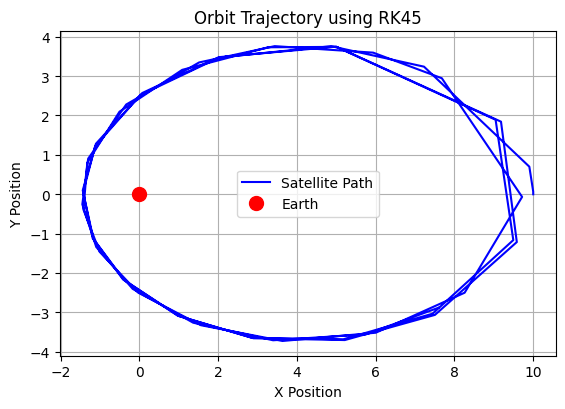

In [2]:
import matplotlib.pyplot as plt
plt.plot(solution.y[0], solution.y[1], label='Satellite Path', color='blue')

plt.plot(0, 0, 'ro', markersize=10, label='Earth')

# Graph Formatting
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Orbit Trajectory using RK45')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal')

plt.show()

## Enhancing Orbital Plot Trajectory using `t_eval`

### What We Did:
We added the `t_eval` parameter (`np.linspace(0, 10, 1000)`) inside the `solve_ivp` function call.

### Why We Did It:
1. **Smooth Visualization:** Because RK45 uses adaptive time-stepping, it takes large time steps ($dt$) at apogee (where gravitational change is slow). When plotted, these sparse points created straight, blocky line segments.
2. **Dense Interpolation:** `t_eval` forces the solver to evaluate and output positions at fine, closely spaced time intervals ($1000$ points) by interpolating between RK45 steps.
3. **Maintaining Efficiency:** It makes the orbit graph visually smooth without altering the underlying RK45 adaptive step calculations or slowing down the simulation.

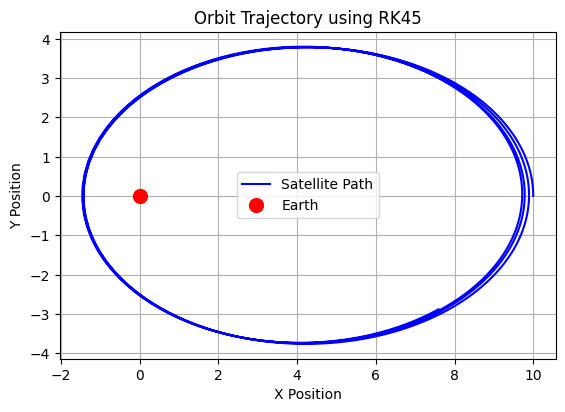

In [3]:
t_points = np.linspace(0, 10, 1000)

solution = solve_ivp(
    fun=orbit_derivatives,
    t_span=(0, 10),
    y0=Y0,
    method='RK45',
    t_eval=t_points
)
import matplotlib.pyplot as plt
plt.plot(solution.y[0], solution.y[1], label='Satellite Path', color='blue')

plt.plot(0, 0, 'ro', markersize=10, label='Earth')

# Graph Formatting
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Orbit Trajectory using RK45')
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal')

plt.show()